In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
 
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (16, 6)
plt.rcParams["figure.dpi"] = 120

In [6]:
DATA_DIR = Path("../raw_data")
 
train = pd.read_parquet(DATA_DIR / "train.parquet")
test = pd.read_parquet(DATA_DIR / "test.parquet")
targets = pd.read_csv(DATA_DIR / "target_channels.csv")
 
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Target channels: {targets.shape}")

Train shape: (14728321, 89)
Test shape:  (521280, 88)
Target channels: (58, 1)


In [7]:
train.head()

,id,channel_1,channel_10,channel_11,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,...,telecommand_351,telecommand_352,telecommand_353,telecommand_354,telecommand_36,telecommand_376,telecommand_38,telecommand_39,telecommand_40,is_anomaly
0,0,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,3,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,4,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [8]:
train.dtypes

id                   int64
channel_1          float32
channel_10         float32
channel_11         float32
channel_12         float32
                    ...   
telecommand_376    float64
telecommand_38     float64
telecommand_39     float64
telecommand_40     float64
is_anomaly           uint8
Length: 89, dtype: object

In [9]:
train.describe()

,id,channel_1,channel_10,channel_11,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,...,telecommand_351,telecommand_352,telecommand_353,telecommand_354,telecommand_36,telecommand_376,telecommand_38,telecommand_39,telecommand_40,is_anomaly
count,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,...,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07
mean,7.364160e+06,1.380301e-01,6.403504e-09,4.395080e-10,2.557318e-01,3.094885e-01,2.720448e-01,1.210223e-01,7.610638e-01,2.927625e-01,...,1.629514e-06,1.765306e-06,1.901099e-06,1.901099e-06,4.481163e-06,3.123234e-06,2.376374e-06,2.580063e-06,2.580063e-06,1.048391e-01
std,4.251700e+06,4.428727e-03,1.492817e-06,2.467632e-07,5.158953e-02,5.081466e-02,9.578262e-02,6.525146e-02,7.655781e-02,5.072071e-02,...,1.276523e-03,1.328647e-03,1.378802e-03,1.378802e-03,2.116871e-03,1.767265e-03,1.541547e-03,1.606256e-03,1.606256e-03,3.063460e-01
min,0.000000e+00,9.217216e-02,0.000000e+00,0.000000e+00,1.225953e-01,1.721236e-01,7.845081e-02,1.286942e-03,7.355139e-03,1.422070e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.682080e+06,1.379103e-01,0.000000e+00,0.000000e+00,2.126752e-01,2.672639e-01,2.142259e-01,7.987051e-02,7.042502e-01,2.499678e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.364160e+06,1.379103e-01,0.000000e+00,0.000000e+00,2.547867e-01,3.078156e-01,2.594865e-01,1.185188e-01,7.612530e-01,2.906744e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.104624e+07,1.379103e-01,0.000000e+00,0.000000e+00,2.953383e-01,3.483671e-01,3.062542e-01,1.520136e-01,8.237714e-01,3.328890e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.472832e+07,4.331867e-01,4.236102e-04,4.218630e-04,9.967715e-01,9.919286e-01,9.710565e-01,5.413337e-01,9.140906e-01,9.843958e-01,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [10]:
print("Columns:", train.columns.tolist()[:20], "...")
print(f"\nTotal columns: {len(train.columns)}")

Columns: ['id', 'channel_1', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_2', 'channel_20', 'channel_21', 'channel_22', 'channel_23', 'channel_24', 'channel_25', 'channel_26'] ...

Total columns: 89


In [12]:
print(targets.head(20))

   target_channels
0       channel_12
1       channel_13
2       channel_14
3       channel_15
4       channel_16
5       channel_17
6       channel_18
7       channel_19
8       channel_20
9       channel_21
10      channel_22
11      channel_23
12      channel_24
13      channel_25
14      channel_26
15      channel_27
16      channel_28
17      channel_29
18      channel_30
19      channel_31


In [13]:
label_candidates = [c for c in train.columns if any(
    kw in c.lower() for kw in ["label", "anomaly", "target", "is_"]
)]
print("Possible label columns:", label_candidates)

Possible label columns: ['is_anomaly']


In [15]:
STARTER_CHANNELS = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

In [16]:
LABEL_COL = "is_anomaly" 

In [17]:
subset = train[STARTER_CHANNELS].copy()
subset.describe()

,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46
count,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07
mean,8.082077e-01,7.821209e-01,7.685694e-01,7.940099e-01,8.103804e-01,7.656219e-01
std,3.117312e-02,3.104107e-02,3.194150e-02,3.466514e-02,3.144005e-02,3.055148e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.055143e-01,7.783114e-01,7.663610e-01,7.913063e-01,8.066803e-01,7.610731e-01
50%,8.094388e-01,7.831301e-01,7.703173e-01,7.960299e-01,8.117668e-01,7.669848e-01
75%,8.141486e-01,7.895566e-01,7.742736e-01,8.007520e-01,8.168547e-01,7.728950e-01
max,9.821104e-01,9.662727e-01,9.507276e-01,9.755059e-01,1.000000e+00,9.595303e-01


In [18]:
missing = subset.isna().sum()
missing_pct = (missing / len(subset) * 100).round(2)
print(pd.DataFrame({"missing": missing, "pct": missing_pct}))

            missing  pct
channel_41        0  0.0
channel_42        0  0.0
channel_43        0  0.0
channel_44        0  0.0
channel_45        0  0.0
channel_46        0  0.0


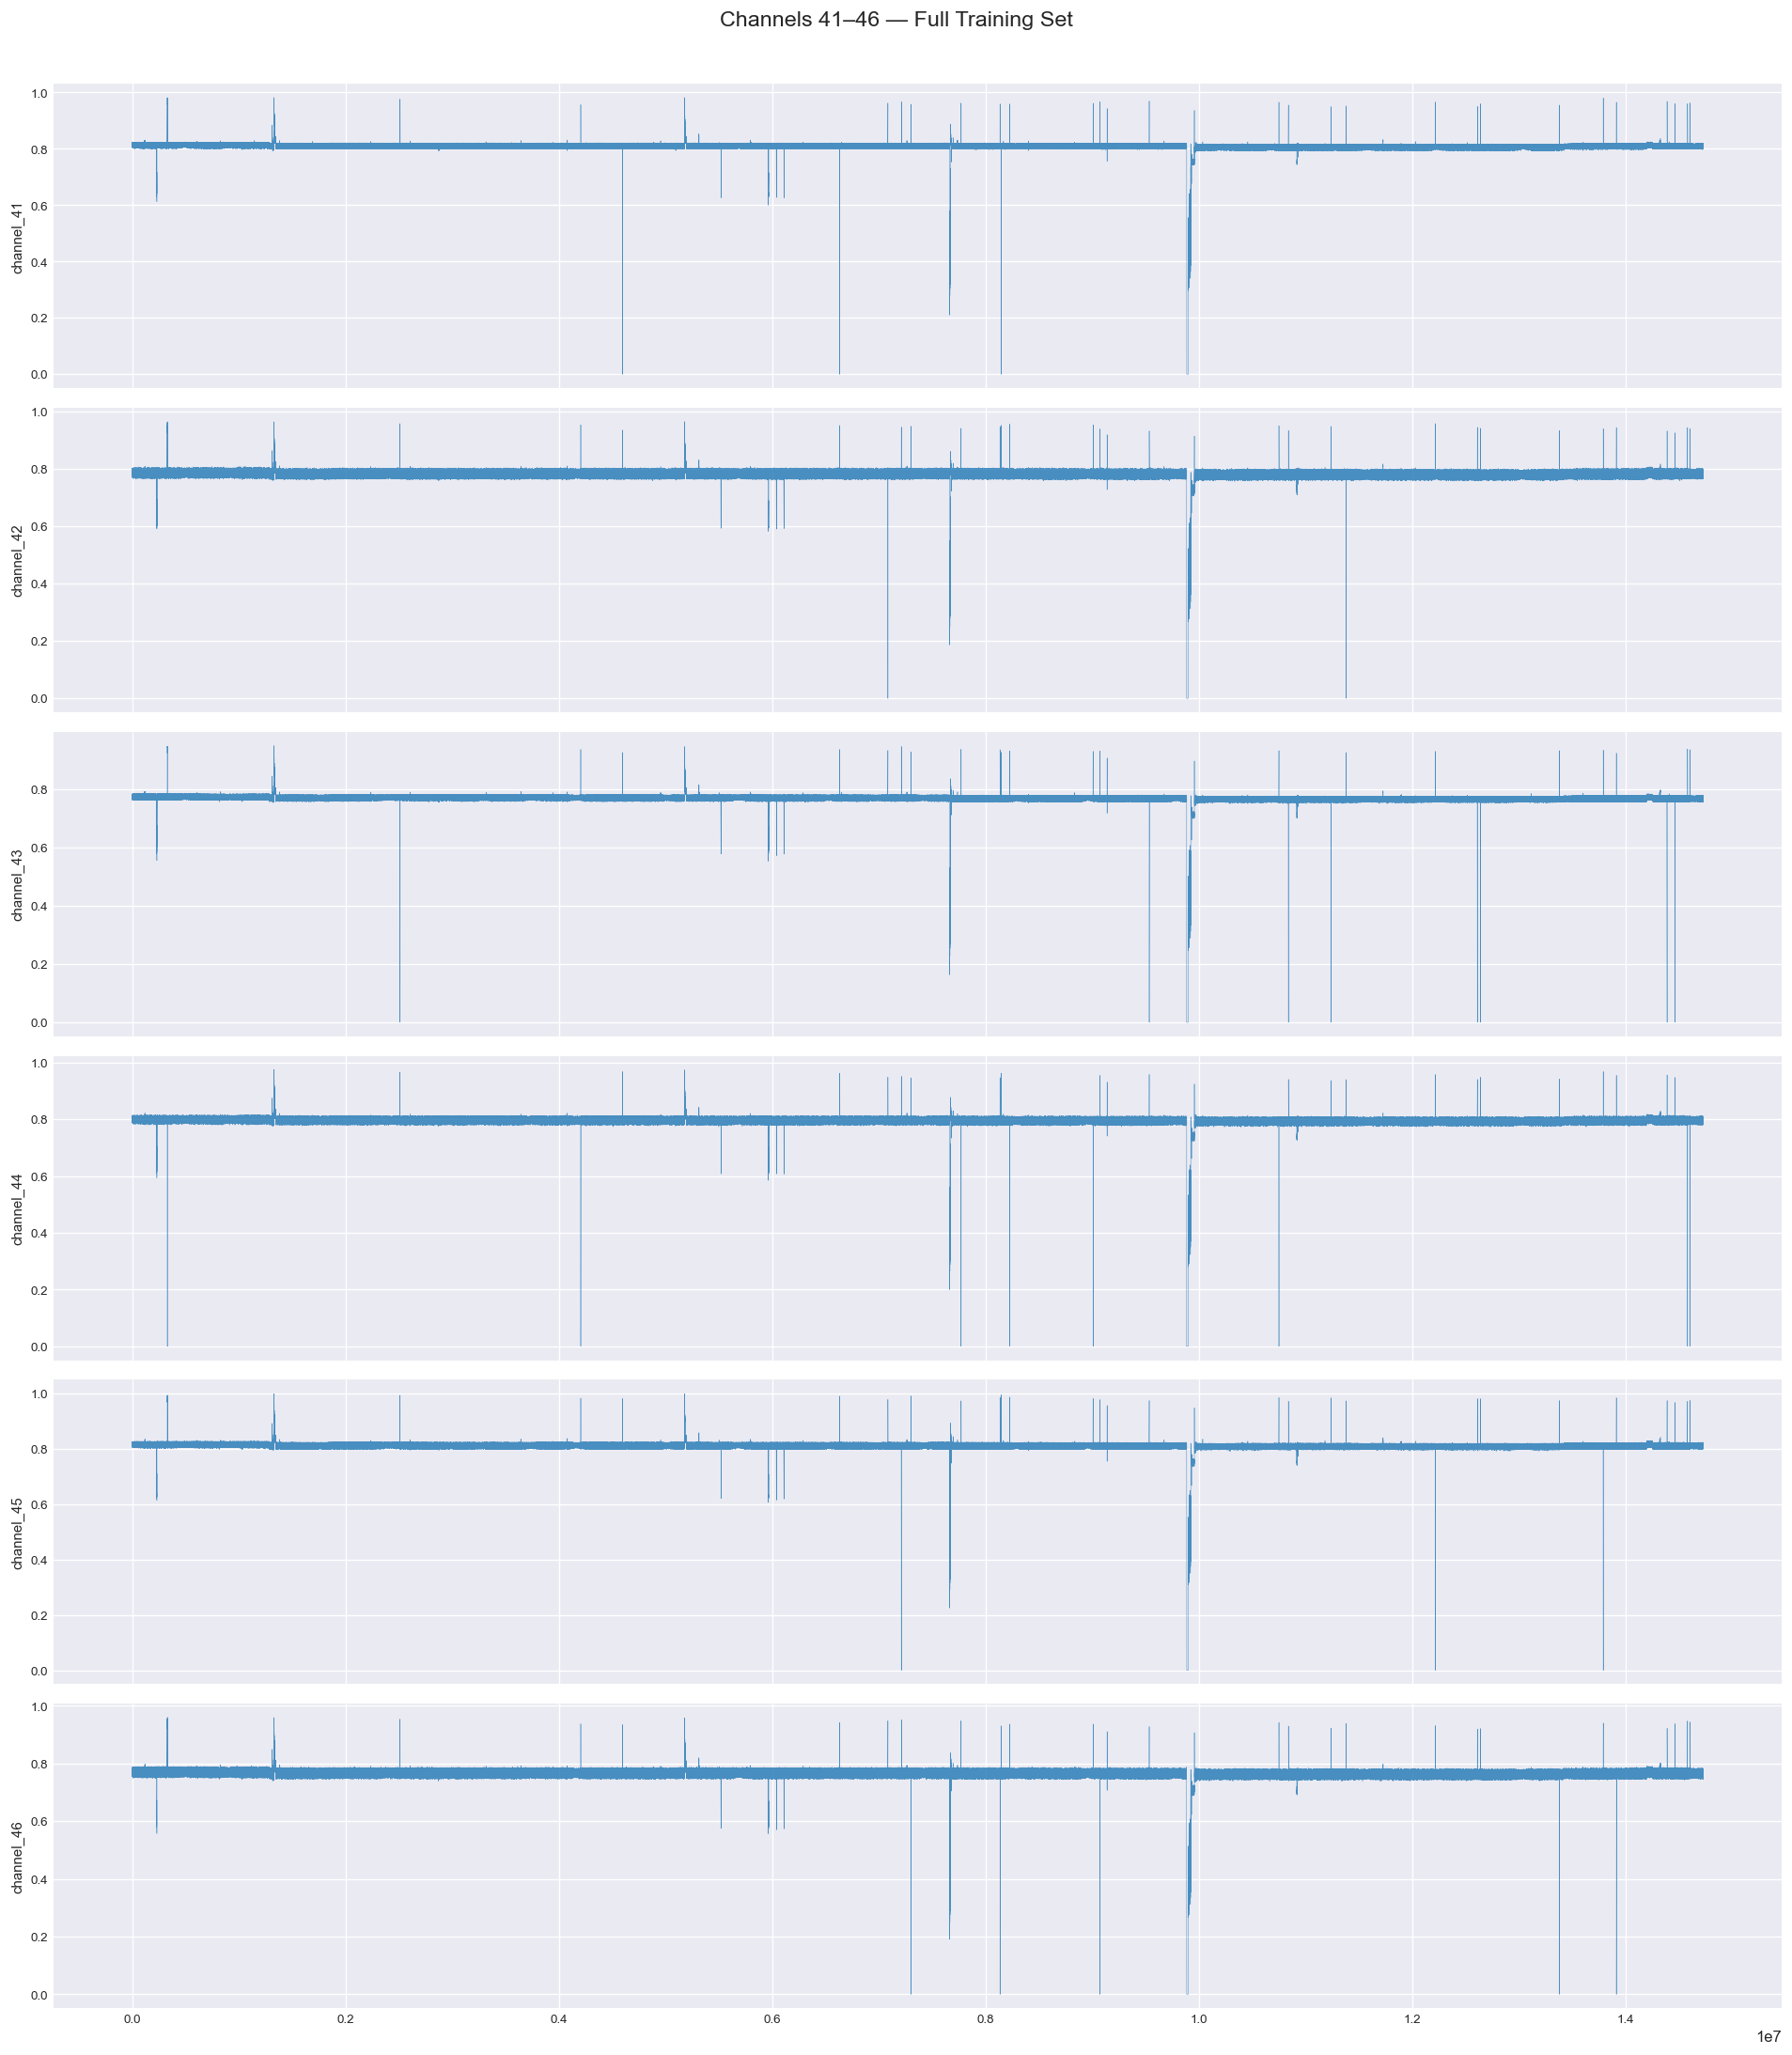

In [21]:
fig, axes = plt.subplots(len(STARTER_CHANNELS), 1, figsize=(16, 3 * len(STARTER_CHANNELS)), sharex=True)
if len(STARTER_CHANNELS) == 1:
    axes = [axes]
 
for ax, ch in zip(axes, STARTER_CHANNELS):
    ax.plot(subset[ch], linewidth=0.3, alpha=0.8)
    ax.set_ylabel(ch, fontsize=9)
    ax.tick_params(labelsize=8)
 
fig.suptitle("Channels 41–46 — Full Training Set", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

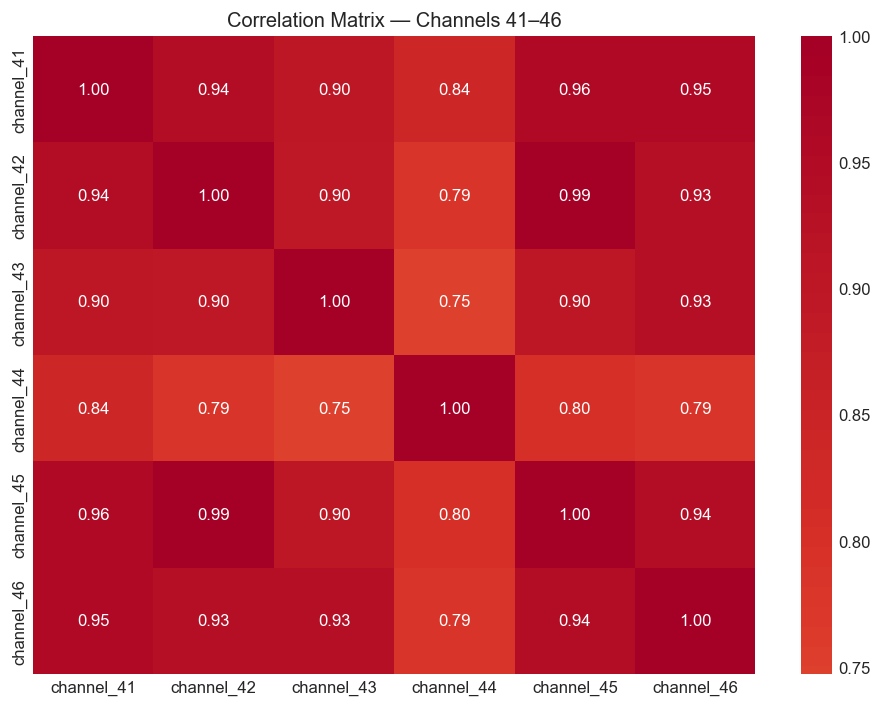

In [22]:
corr = subset.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, ax=ax)
ax.set_title("Correlation Matrix — Channels 41–46")
plt.tight_layout()
plt.show()

In [23]:
corr_abs = corr.abs()
np.fill_diagonal(corr_abs.values, 0)
most_corr = corr_abs.stack().idxmax()
print(f"Most correlated pair: {most_corr}")

Most correlated pair: ('channel_42', 'channel_45')


In [24]:
ch_a, ch_b = most_corr
WINDOW = 500 

/var/folders/1g/y1cwhtgn35gf0xmzck265m5r0000gn/T/ipykernel_62605/3057081657.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/cewen/.pyenv/versions/3.10.6/envs/sentinel/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


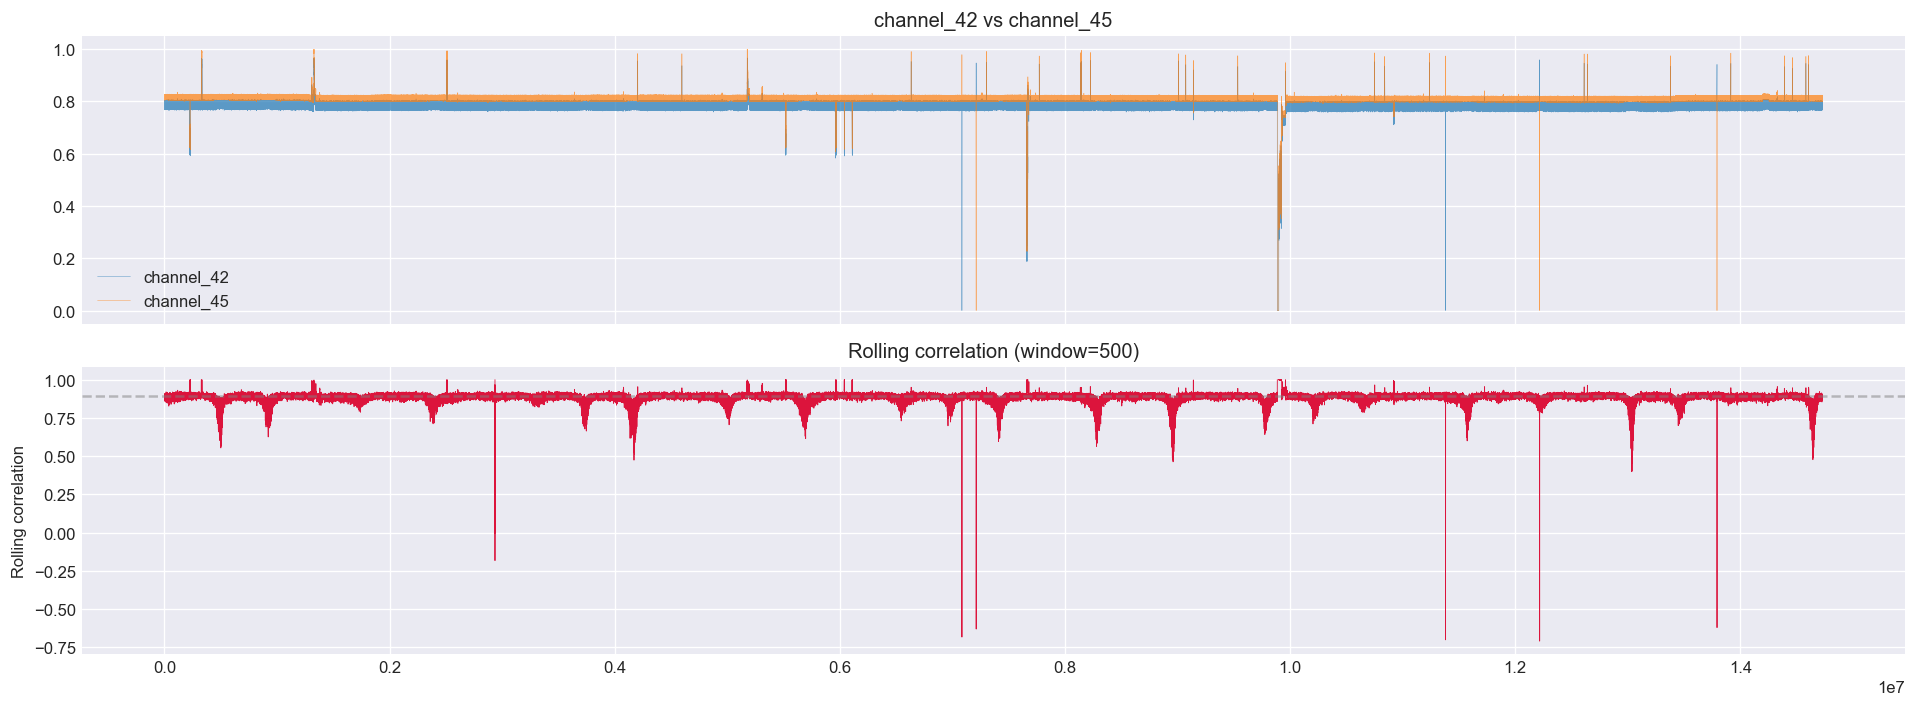

In [25]:
rolling_corr = subset[ch_a].rolling(WINDOW).corr(subset[ch_b])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
ax1.plot(subset[ch_a], linewidth=0.3, alpha=0.7, label=ch_a)
ax1.plot(subset[ch_b], linewidth=0.3, alpha=0.7, label=ch_b)
ax1.legend()
ax1.set_title(f"{ch_a} vs {ch_b}")
 
ax2.plot(rolling_corr, linewidth=0.5, color="crimson")
ax2.axhline(y=rolling_corr.median(), color="grey", linestyle="--", alpha=0.5)
ax2.set_ylabel("Rolling correlation")
ax2.set_title(f"Rolling correlation (window={WINDOW})")
plt.tight_layout()
plt.show()

In [26]:
labels = train[LABEL_COL]
print(f"Label distribution:\n{labels.value_counts()}")
print(f"\nAnomaly rate: {labels.mean():.4%}")

Label distribution:
is_anomaly
0    13184217
1     1544104
Name: count, dtype: int64

Anomaly rate: 10.4839%


In [28]:
anomaly_mask = labels == 1
anomaly_indices = np.where(anomaly_mask)[0]

# Find contiguous anomaly segments
diffs = np.diff(anomaly_indices)
segment_starts = np.concatenate([[anomaly_indices[0]], anomaly_indices[1:][diffs > 1]])
segment_ends = np.concatenate([anomaly_indices[:-1][diffs > 1], [anomaly_indices[-1]]])

print(f"Number of anomaly segments: {len(segment_starts)}")
print(f"Segment lengths:\n{pd.Series(segment_ends - segment_starts + 1).describe()}")

Number of anomaly segments: 190
Segment lengths:
count       190.000000
mean       8126.863158
std       15114.108367
min           1.000000
25%          25.000000
50%         601.500000
75%        9081.000000
max      116061.000000
dtype: float64


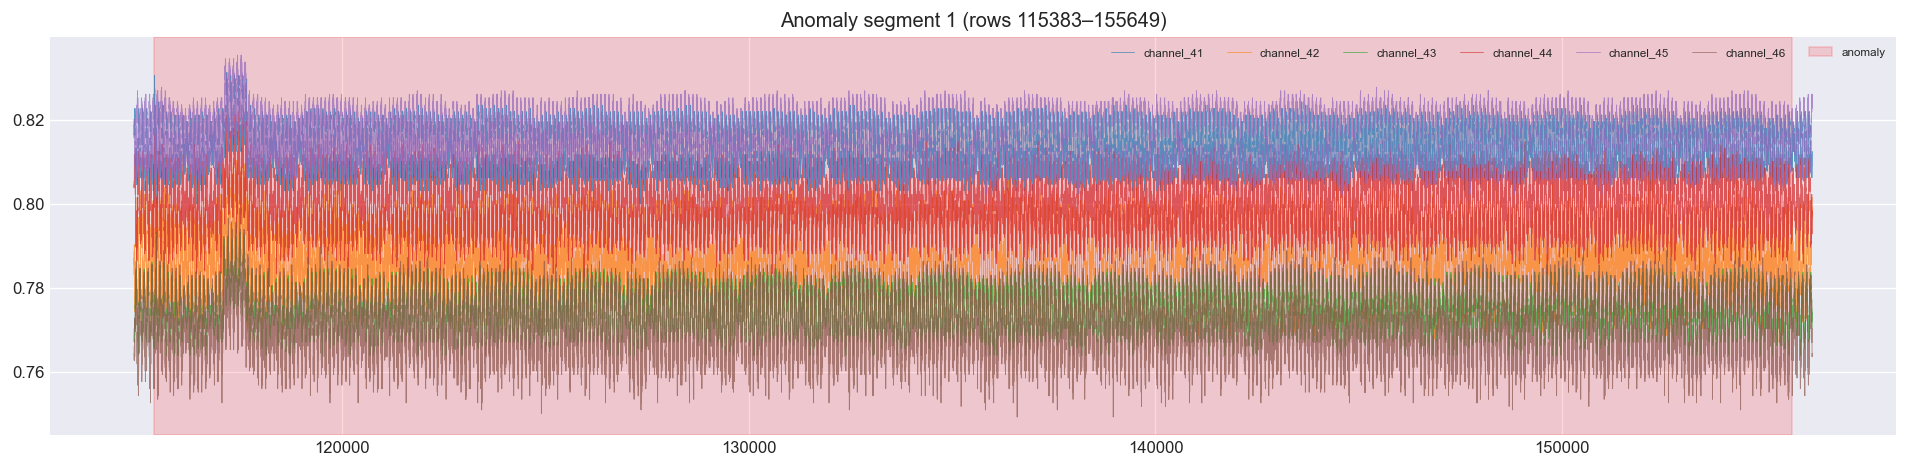

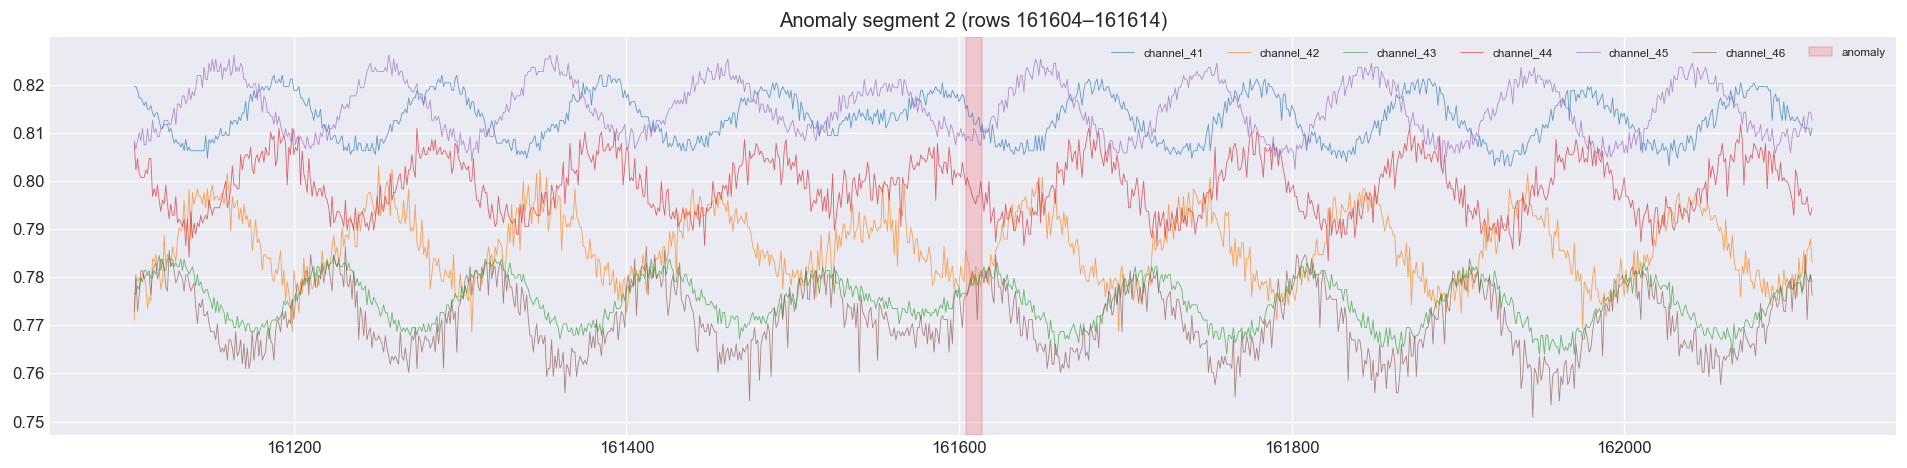

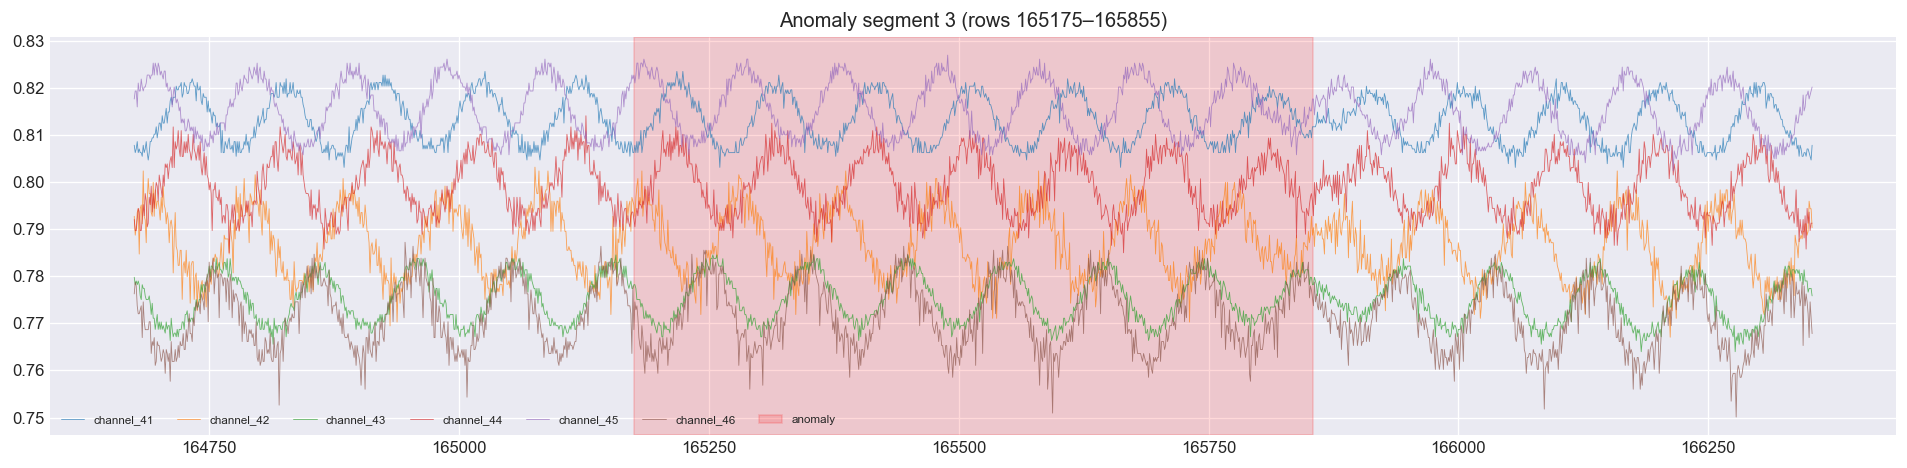

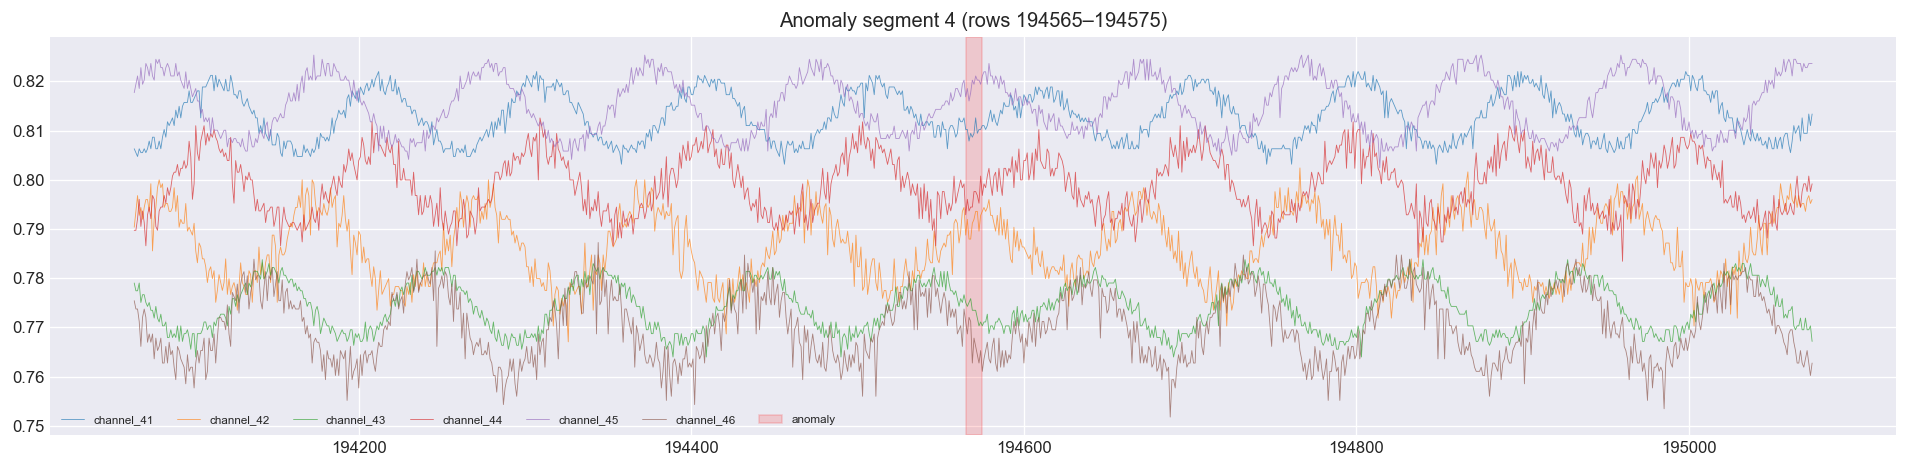

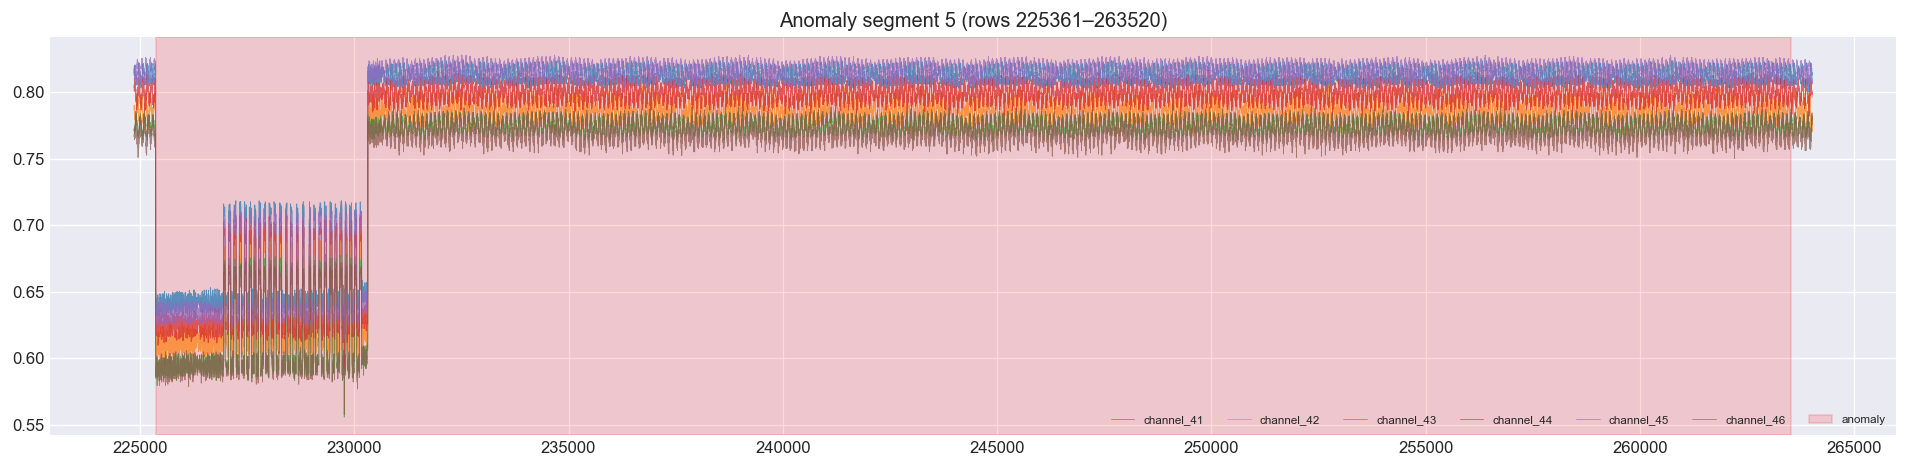

In [29]:
# Plot first N anomaly windows with context
N_WINDOWS = 5
CONTEXT = 500  # rows of context either side

for i in range(min(N_WINDOWS, len(segment_starts))):
     start = max(0, segment_starts[i] - CONTEXT)
     end = min(len(train), segment_ends[i] + CONTEXT)
     window = subset.iloc[start:end]
     window_labels = labels.iloc[start:end]

     fig, ax = plt.subplots(figsize=(16, 4))
     for ch in STARTER_CHANNELS:
         ax.plot(window.index, window[ch], linewidth=0.5, alpha=0.7, label=ch)

     # Shade anomaly region
     anomaly_region = window_labels == 1
     if anomaly_region.any():
         ax.axvspan(
             window.index[anomaly_region].min(),
             window.index[anomaly_region].max(),
             alpha=0.15, color="red", label="anomaly"
         )
     ax.legend(fontsize=7, ncol=7)
     ax.set_title(f"Anomaly segment {i+1} (rows {segment_starts[i]}–{segment_ends[i]})")
     plt.tight_layout()
     plt.show()

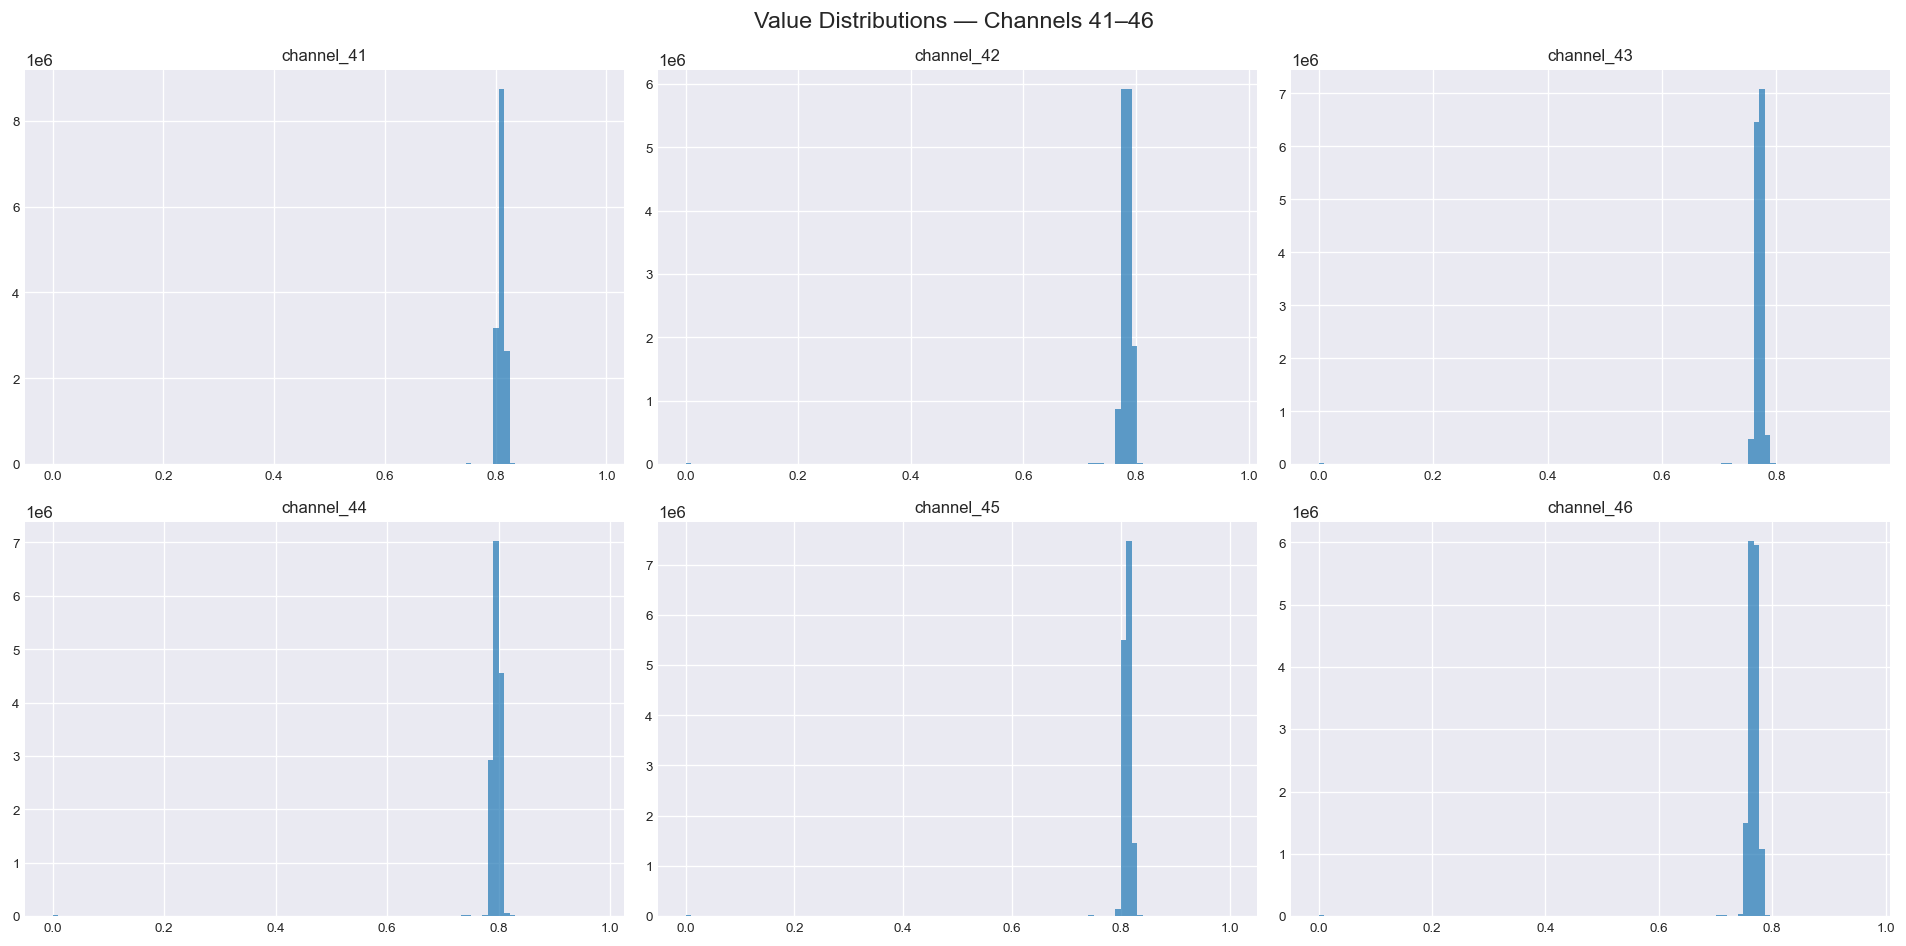

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, ch in zip(axes.flat, STARTER_CHANNELS):
    subset[ch].dropna().hist(bins=100, ax=ax, alpha=0.7, edgecolor="none")
    ax.set_title(ch, fontsize=10)
    ax.tick_params(labelsize=8)
plt.suptitle("Value Distributions — Channels 41–46", fontsize=14)
plt.tight_layout()
plt.show()

/Users/cewen/.pyenv/versions/3.10.6/envs/sentinel/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cewen/.pyenv/versions/3.10.6/envs/sentinel/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cewen/.pyenv/versions/3.10.6/envs/sentinel/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cewen/.pyenv/versions/3.10.6/envs/sentinel/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cewen/.pyenv/versions/3.10.6/envs/sentinel/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.inte

R²: 0.9633
Residual std: 0.0060


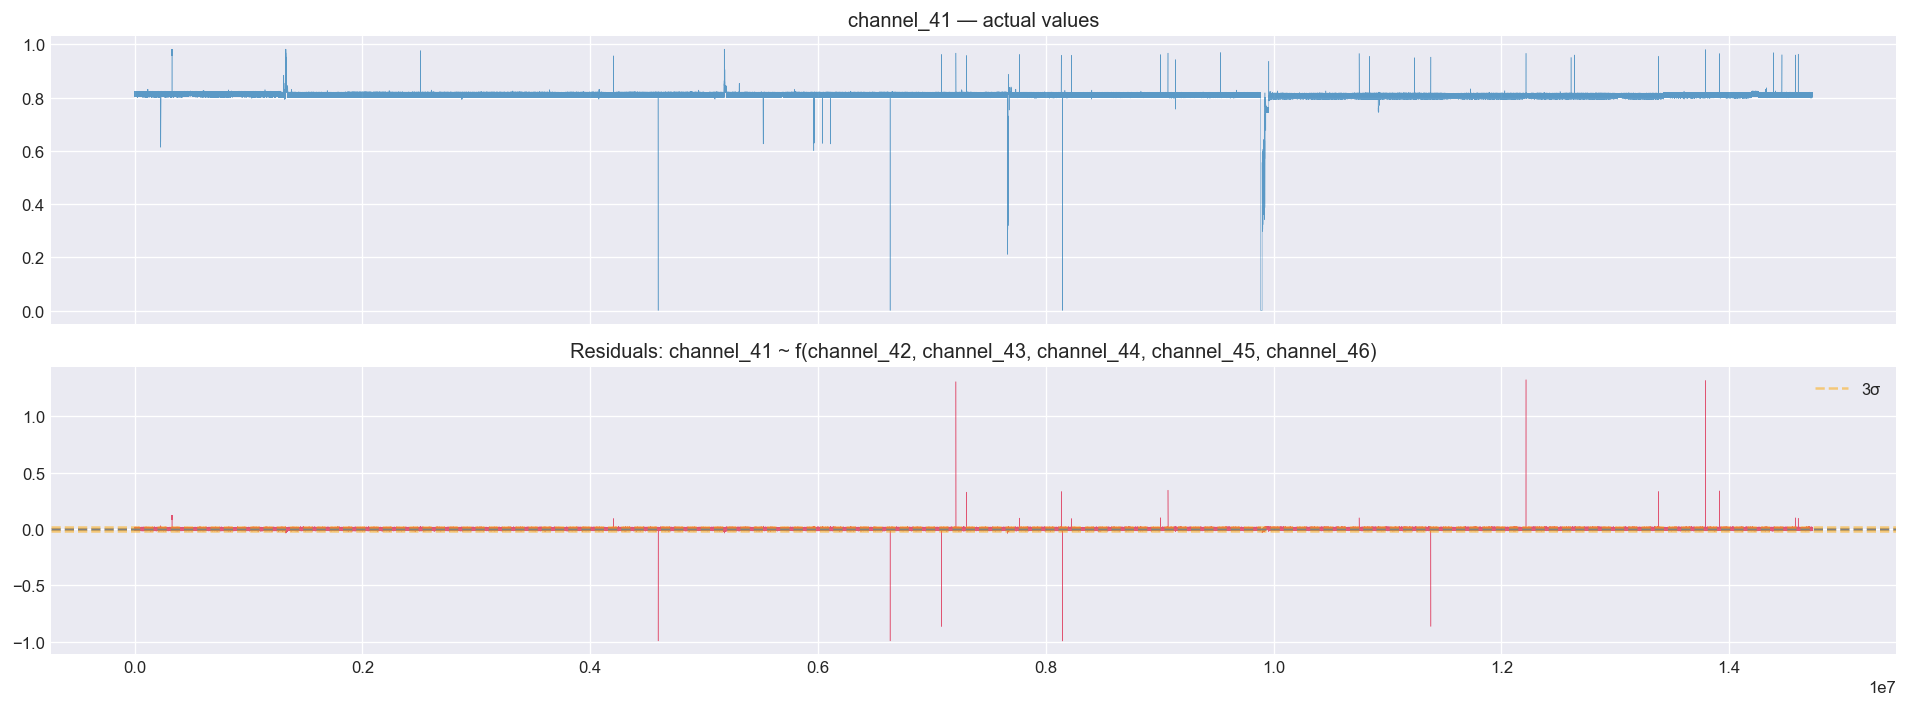

In [31]:
from sklearn.linear_model import LinearRegression
 
target_ch = STARTER_CHANNELS[0]
feature_chs = STARTER_CHANNELS[1:]
 
clean = subset.dropna()
X = clean[feature_chs].values
y = clean[target_ch].values
 
lr = LinearRegression().fit(X, y)
residuals = y - lr.predict(X)
 
print(f"R²: {lr.score(X, y):.4f}")
print(f"Residual std: {residuals.std():.4f}")
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
ax1.plot(clean.index, y, linewidth=0.3, alpha=0.7)
ax1.set_title(f"{target_ch} — actual values")
 
ax2.plot(clean.index, residuals, linewidth=0.3, color="crimson", alpha=0.7)
ax2.axhline(y=0, color="grey", linestyle="--")
ax2.axhline(y=3 * residuals.std(), color="orange", linestyle="--", alpha=0.5, label="3σ")
ax2.axhline(y=-3 * residuals.std(), color="orange", linestyle="--", alpha=0.5)
ax2.set_title(f"Residuals: {target_ch} ~ f({', '.join(feature_chs)})")
ax2.legend()
plt.tight_layout()
plt.show()

# EDA Findings — Channels 41–46

## Dataset overview

The training set contains 14.7M rows across 6 channels (`channel_41`–`channel_46`), all standardised to a 0–1 range. Values are tightly concentrated around 0.77–0.81 with low variance (std ~0.03). There are no missing values across any channel.

The label column `is_anomaly` flags 10.5% of rows as anomalous, distributed across 190 distinct segments. Segment lengths vary enormously: median 601 rows, but ranging from single-point events (min 1) to extended periods of over 116k rows.

## Channel relationships

All six channels are highly correlated (0.75–0.99). The strongest pair is `channel_42`/`channel_45` at 0.99. `channel_44` is the most loosely coupled, with correlations of 0.75–0.80 against the rest of the block.

Rolling correlation (window=500) between `channel_42` and `channel_45` holds steady around 0.90 but drops sharply and repeatedly at localised points throughout the series. These drops align visually with the spike anomalies seen in the time series plots.

## Anomaly types

Visual inspection of labelled anomaly windows reveals at least three distinct event types:

1. **Extended oscillatory events** (e.g. segment 1, ~40k rows): All channels oscillate within their normal range. No obvious deviation — may represent rare nominal events rather than faults. These are likely the hardest to detect.
2. **Point/short-burst spikes** (e.g. segments 2 and 4, ~10 rows): Sharp, narrow deviations in one or more channels. Clean signal, easy to detect but risk over-triggering false positives on similar-looking normal noise.
3. **Regime shifts** (e.g. segment 5, ~38k rows): Sustained drop in channel values (from ~0.8 to ~0.6) with high-frequency oscillation at onset before stabilising. Distinct from normal operating behaviour.

## Linear residual baseline

A simple linear regression predicting `channel_41` from the remaining five channels achieves R²=0.963 with residual std of 0.006. Residual spikes are clean, sparse, and well-separated from baseline noise — indicating that even a basic inter-channel model captures enough of the normal relationship to flag major deviations. The 3σ threshold visually separates the large spike events from background.

## Key observations for modelling

- The anomaly label covers both true faults and rare nominal events, which the model must detect equally.
- The extreme variation in segment length (1–116k rows) means a single detection threshold or window size is unlikely to work across all event types.
- `channel_44`'s weaker coupling to the block makes it a candidate for targeted residual monitoring.
- The high anomaly rate (10.5%) is misleading — most anomalous rows belong to a small number of long segments. The 190 event count is the operationally relevant number.
- The F0.5 scoring penalises false positives heavily, so precision on the short-burst spikes is critical.

In [32]:

# # Corrected Event-wise F0.5 Score
#
# Implementation of the ESA-ADB evaluation metric based on:
# - Kotowski et al. (2024), "European Space Agency Benchmark for Anomaly
#   Detection in Satellite Telemetry" (arXiv:2406.17826)
# - Sehili & Zhang (2023), "Multivariate Time Series Anomaly Detection:
#   Fancy Algorithms and Flawed Evaluation Methodology" (arXiv:2308.13068)
#
# The metric works as follows:
#
# 1. **Event-wise** — contiguous segments of anomaly labels are treated as
#    single events.  A ground-truth event counts as detected (TP_e) if the
#    prediction overlaps with it by at least one point.  A predicted segment
#    that overlaps no ground-truth event is a false positive event (FP_e).
#    A ground-truth event with zero overlap is a false negative event (FN_e).
#
# 2. **Corrected precision** — naive event-wise precision has a flaw: an
#    algorithm that fires a single point per event gets perfect precision
#    even if it *also* fires millions of other points.  The correction
#    scales each event-wise FP by the ratio of time-level false-positive
#    duration to total nominal duration:
#
#        Prec_corr = TP_e / (TP_e + FP_e × (FP_t / N_t))
#
#    where FP_t = total number of nominal time points predicted as anomalous,
#    and N_t = total number of nominal time points.
#
# 3. **F_beta with beta=0.5** — weights precision higher than recall:
#
#        F_0.5 = (1 + 0.25) × Prec_corr × Rec_e / (0.25 × Prec_corr + Rec_e)

# %%
import numpy as np
import pandas as pd
from typing import NamedTuple


class ScoringResult(NamedTuple):
    """Container for all metric components."""
    f05: float
    precision_corrected: float
    recall_event: float
    tp_events: int
    fp_events: int
    fn_events: int
    fp_time: int
    nominal_time: int
    n_true_events: int
    n_pred_events: int


def _get_segments(binary_array: np.ndarray) -> list[tuple[int, int]]:
    """Extract contiguous segments of 1s from a binary array.

    Returns a list of (start_idx, end_idx) tuples where end_idx is
    inclusive, matching the convention used in ESA-ADB.
    """
    if len(binary_array) == 0:
        return []

    segments = []
    in_segment = False
    start = 0

    for i, val in enumerate(binary_array):
        if val == 1 and not in_segment:
            start = i
            in_segment = True
        elif val == 0 and in_segment:
            segments.append((start, i - 1))
            in_segment = False

    if in_segment:
        segments.append((start, len(binary_array) - 1))

    return segments


def _segments_overlap(seg_a: tuple[int, int], seg_b: tuple[int, int]) -> bool:
    """Check if two (start, end) segments overlap by at least one point."""
    return seg_a[0] <= seg_b[1] and seg_b[0] <= seg_a[1]


def corrected_eventwise_f05(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    beta: float = 0.5,
) -> ScoringResult:
    """Compute the corrected event-wise F-beta score.

    Parameters
    ----------
    y_true : np.ndarray
        Binary ground-truth labels (1 = anomaly, 0 = nominal).
    y_pred : np.ndarray
        Binary predicted labels (1 = anomaly, 0 = nominal).
    beta : float
        F-score beta parameter. Default 0.5 (precision-heavy).

    Returns
    -------
    ScoringResult
        Named tuple with all metric components for inspection.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    assert len(y_true) == len(y_pred), "Arrays must have equal length"

    # --- Extract event segments ---
    true_segments = _get_segments(y_true)
    pred_segments = _get_segments(y_pred)

    # --- Event-wise TP, FP, FN ---
    # A true event is TP if ANY predicted segment overlaps it
    true_detected = np.zeros(len(true_segments), dtype=bool)
    pred_matched = np.zeros(len(pred_segments), dtype=bool)

    for i, t_seg in enumerate(true_segments):
        for j, p_seg in enumerate(pred_segments):
            if _segments_overlap(t_seg, p_seg):
                true_detected[i] = True
                pred_matched[j] = True

    tp_e = int(true_detected.sum())
    fn_e = int((~true_detected).sum())
    fp_e = int((~pred_matched).sum())

    # --- Time-level false positive stats ---
    # Nominal points = where y_true == 0
    nominal_mask = y_true == 0
    n_t = int(nominal_mask.sum())  # total nominal time points
    # FP_t = nominal points that were predicted as anomaly
    fp_t = int((nominal_mask & (y_pred == 1)).sum())

    # --- Corrected precision ---
    if tp_e + fp_e == 0:
        prec_corr = 0.0
    elif n_t == 0:
        # Edge case: everything is anomalous in ground truth
        prec_corr = 1.0 if fp_e == 0 else 0.0
    else:
        fp_weight = fp_t / n_t  # ratio of FP time to nominal time
        prec_corr = tp_e / (tp_e + fp_e * fp_weight)

    # --- Event-wise recall ---
    if tp_e + fn_e == 0:
        rec_e = 0.0
    else:
        rec_e = tp_e / (tp_e + fn_e)

    # --- F-beta ---
    beta_sq = beta ** 2
    if prec_corr + rec_e == 0:
        f_beta = 0.0
    else:
        f_beta = (1 + beta_sq) * prec_corr * rec_e / (beta_sq * prec_corr + rec_e)

    return ScoringResult(
        f05=f_beta,
        precision_corrected=prec_corr,
        recall_event=rec_e,
        tp_events=tp_e,
        fp_events=fp_e,
        fn_events=fn_e,
        fp_time=fp_t,
        nominal_time=n_t,
        n_true_events=len(true_segments),
        n_pred_events=len(pred_segments),
    )


# %% [markdown]
# ## Sanity checks

# %%
def _print_result(name: str, result: ScoringResult):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  F0.5:               {result.f05:.4f}")
    print(f"  Precision (corr):   {result.precision_corrected:.4f}")
    print(f"  Recall (event):     {result.recall_event:.4f}")
    print(f"  TP/FP/FN events:    {result.tp_events}/{result.fp_events}/{result.fn_events}")
    print(f"  True/Pred events:   {result.n_true_events}/{result.n_pred_events}")
    print(f"  FP time / Nominal:  {result.fp_time}/{result.nominal_time}")


# %%
# --- Test 1: Perfect prediction ---
y_true = np.array([0,0,0,1,1,1,0,0,0,0,1,1,0,0])
y_pred = np.array([0,0,0,1,1,1,0,0,0,0,1,1,0,0])
_print_result("Perfect prediction", corrected_eventwise_f05(y_true, y_pred))
# Expected: F0.5 = 1.0

# %%
# --- Test 2: Missed one event entirely ---
y_true = np.array([0,0,0,1,1,1,0,0,0,0,1,1,0,0])
y_pred = np.array([0,0,0,1,1,1,0,0,0,0,0,0,0,0])
_print_result("Missed one event", corrected_eventwise_f05(y_true, y_pred))
# Expected: recall = 0.5, precision = 1.0, F0.5 weighted toward precision

# %%
# --- Test 3: All nominal predicted as anomaly ---
# NOTE: This is a known edge case. One giant predicted segment matches all
# true events, so FP_e = 0 and the correction has nothing to scale. The
# metric was designed for realistic detectors producing many small segments,
# not degenerate all-ones submissions. In practice this is not a problem.
y_true = np.array([0,0,0,1,1,1,0,0,0,0,1,1,0,0])
y_pred = np.array([1,1,1,1,1,1,1,1,1,1,1,1,1,1])
_print_result("Predict everything as anomaly (degenerate)", corrected_eventwise_f05(y_true, y_pred))

# %%
# --- Test 3b: Realistic noisy detector (many scattered FP segments) ---
# THIS is the case the correction actually catches — lots of small false
# alarms scattered across nominal regions.
y_true = np.array([0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0])
y_pred = np.array([1,0,1,1,1,1,0,1,0,1,0,1,0,1,0,0,1,1,0,1])
_print_result("Noisy detector (many FP segments)", corrected_eventwise_f05(y_true, y_pred))

# %%
# --- Test 4: Sparse single-point detections (one point per true event) ---
y_true = np.array([0,0,0,1,1,1,0,0,0,0,1,1,0,0])
y_pred = np.array([0,0,0,0,1,0,0,0,0,0,1,0,0,0])
_print_result("Minimal overlap (1 point per event)", corrected_eventwise_f05(y_true, y_pred))
# Expected: perfect event-wise detection, no FPs -> F0.5 = 1.0

# %%
# --- Test 5: False alarm on nominal region ---
y_true = np.array([0,0,0,1,1,1,0,0,0,0,1,1,0,0])
y_pred = np.array([0,0,0,1,1,1,1,1,0,0,1,1,0,0])
_print_result("FP bleed into nominal region", corrected_eventwise_f05(y_true, y_pred))
# Note: pred segment [3..7] covers true event [3..5] but also nominal [6..7]
# This is a SINGLE predicted segment overlapping a true event, so event-wise
# it's still 1 TP and 0 FP events. But FP_t increases (2 nominal points
# falsely labelled), which would matter if there were also unmatched pred segments.

# %%
# --- Test 6: Random noise detector ---
rng = np.random.default_rng(42)
n = 100_000
y_true_big = np.zeros(n, dtype=int)
# Insert 10 anomaly events of length ~100
for start in rng.choice(range(1000, n - 1000), size=10, replace=False):
    y_true_big[start:start+100] = 1
# Random predictions at ~5% rate
y_pred_big = (rng.random(n) < 0.05).astype(int)
_print_result("Random 5% detector vs 10 events", corrected_eventwise_f05(y_true_big, y_pred_big))

# %%
# --- Test 7: Predict nothing ---
y_true = np.array([0,0,0,1,1,1,0,0,0,0,1,1,0,0])
y_pred = np.zeros_like(y_true)
_print_result("Predict nothing", corrected_eventwise_f05(y_true, y_pred))
# Expected: F0.5 = 0.0 (recall = 0)


  Perfect prediction
  F0.5:               1.0000
  Precision (corr):   1.0000
  Recall (event):     1.0000
  TP/FP/FN events:    2/0/0
  True/Pred events:   2/2
  FP time / Nominal:  0/9

  Missed one event
  F0.5:               0.8333
  Precision (corr):   1.0000
  Recall (event):     0.5000
  TP/FP/FN events:    1/0/1
  True/Pred events:   2/1
  FP time / Nominal:  0/9

  Predict everything as anomaly (degenerate)
  F0.5:               1.0000
  Precision (corr):   1.0000
  Recall (event):     1.0000
  TP/FP/FN events:    2/0/0
  True/Pred events:   2/1
  FP time / Nominal:  9/9

  Noisy detector (many FP segments)
  F0.5:               0.4717
  Precision (corr):   0.4167
  Recall (event):     1.0000
  TP/FP/FN events:    2/6/0
  True/Pred events:   2/8
  FP time / Nominal:  7/15

  Minimal overlap (1 point per event)
  F0.5:               1.0000
  Precision (corr):   1.0000
  Recall (event):     1.0000
  TP/FP/FN events:    2/0/0
  True/Pred events:   2/2
  FP time / Nominal:  0/9
